In [1]:
import os
import time

from prompt_toolkit .application import get_app

os .environ ['US_TIGER_SHAPEFILE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/TIGER/tl_2020_us_county/tl_2020_us_county.shp'
os .environ ['CANADA_CENSUS_DIVISIONS_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/CanadaBoundaries/lcd_000b21a_e/lcd_000b21a_e.shp'
os .environ ['DATA_CACHE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/'


In [94]:
from research_spring_2025 import load_us_counties
from research_spring_2025 import get_selected_regions
from research_spring_2025 import generate_h3_grid_from_gdf
from research_spring_2025 import get_parent_cells

counties =get_selected_regions ()
h3_cells =generate_h3_grid_from_gdf (counties ,use_cached_file =True )


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib .pyplot as plt

import contextily as ctx

from tqdm import tqdm
from tqdm .contrib .concurrent import thread_map


In [4]:
import rasterio
from rasterstats import zonal_stats

from tqdm .contrib .concurrent import thread_map

import matplotlib .pyplot as plt


In [248]:
def get_stats (geometries ):
    vrt_path ='/Users/aaronspaulding/data/tree_canopy_cover/609802/ETH_GlobalCanopyHeight_10m_2020_mosaic_Map.vrt'

    stats =zonal_stats (
    geometries ,
    vrt_path ,
    stats =['mean','max','min','median','std'],

    nodata =255. ,
    all_touched =True ,
    band =1
    )
    return stats


In [261]:
from more_itertools import chunked
from tqdm .contrib .concurrent import thread_map

chunked_geometries =list (chunked (h3_cells .geometry [:],250 ))


In [262]:
results =thread_map (get_stats ,chunked_geometries ,max_workers =50 )


  0%|          | 0/14287 [00:00<?, ?it/s]

In [264]:
all_mins =[]
all_maxs =[]
all_means =[]
all_medians =[]
all_stds =[]

for r in results :
    all_mins .extend ([r_ ['min']for r_ in r ])
    all_maxs .extend ([r_ ['max']for r_ in r ])
    all_means .extend ([r_ ['mean']for r_ in r ])
    all_medians .extend ([r_ ['median']for r_ in r ])
    all_stds .extend ([r_ ['std']for r_ in r ])

all_mins =np .array (all_mins ,dtype =float )
all_maxs =np .array (all_maxs ,dtype =float )
all_means =np .array (all_means ,dtype =float )
all_medians =np .array (all_medians ,dtype =float )
all_stds =np .array (all_stds ,dtype =float )


In [286]:
h3_cells ['tree_height_min']=-1
h3_cells ['tree_height_max']=-1
h3_cells ['tree_height_mean']=-1
h3_cells ['tree_height_median']=-1
h3_cells ['tree_height_std']=-1


In [287]:
h3_cells ['tree_height_min']=all_mins
h3_cells ['tree_height_max']=all_maxs
h3_cells ['tree_height_mean']=all_means
h3_cells ['tree_height_median']=all_medians
h3_cells ['tree_height_std']=all_stds


<Axes: >

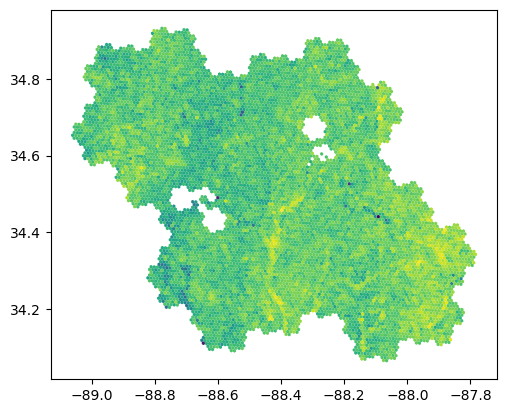

In [288]:
h3_cells [10_600 :20_000 ].copy ().plot (
column ='tree_height_max',
)


In [290]:
h3_cells .drop (columns ='geometry').reset_index (drop =True ).to_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_tree_canopy_height.feather')


In [289]:
h3_cells .columns


Index(['index', 'geometry', 'tree_height_min', 'tree_height_max',
       'tree_height_mean', 'tree_height_median', 'tree_height_std'],
      dtype='object')